# **Random Projection:** Applied Machine Learning Exercise

## 1. Objective
This notebook evaluates the impact of **Random Projection (RP)** on classification performance across different datasets. The aim is to understand how dimensionality reduction influences the accuracy and efficiency of machine learning models applied to **text** and **image** data.

## 2. Datasets
1. **Text Dataset (20 Newsgroups):**  
   Around 18,000 news articles categorized into 20 topics.
2. **Image Dataset (Emotion Detection):**  
   15,000 facial emotion images labeled with 6 emotion classes.

## 3. Research Questions
1. How does **Sparse Random Projection (SRP)** affect classification performance across different classifiers and datasets?
2. How does the dimensionality recommended by the **Johnson–Lindenstrauss Lemma** relate to classification accuracy?
3. How does RP influence feature quality in nonlinear datasets? Can combining RP with **deep learning** provide a balance between dimensionality reduction and feature preservation?

## 4. Technical Highlights
- Applied **SRP** to both datasets for dimensionality reduction.
- Trained and tested models including **Logistic Regression**, **Random Forest**, and **K-Nearest Neighbors (KNN)** on both original and reduced data.
- Evaluated how the dimensionality suggested by the **JL Lemma** affects model accuracy and computational speed.
- Visualized results using:
  - **Confusion matrices** for prediction evaluation
  - **Accuracy plots** across reduced dimensions
- Explored combining RP with **deep learning feature extractors** to maintain key information after reduction.
- Used **Python (Jupyter Notebook)** with **scikit-learn, matplotlib, seaborn, pandas, numpy** for all analyses.

# **Part 1: Text Dataset Modeling with SRP and Classifiers (20 Newsgroups)**
We apply Sparse Random Projection to the text dataset and evaluate the performance of different classifiers and assess how they align with the JL Lemma’s recommended dimensions for preserving pairwise distances.

## Step 1: Fetch Data from Sklearn

In [3]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Sklearn for datasets, text vectorization, and models
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.random_projection import SparseRandomProjection
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed

# TensorFlow/Keras libraries for image processing
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# OpenCV for image processing
import cv2

# KaggleHub for additional functionality
import kagglehub

# Progress bar for image loading
from tqdm import tqdm

In [5]:
# Fetch the 20 newsgroups dataset
newsgroups = fetch_20newsgroups(subset='all')
X_raw, y = newsgroups.data, newsgroups.target  # Unpack directly into variables

# Vectorize the text data using TfidfVectorizer with max_features = 2000
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000)
X = vectorizer.fit_transform(X_raw)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shapes and unique labels information
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}")

X shape: (18846, 2000)
y shape: (18846,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


## Step 2: Confirm the Dataset

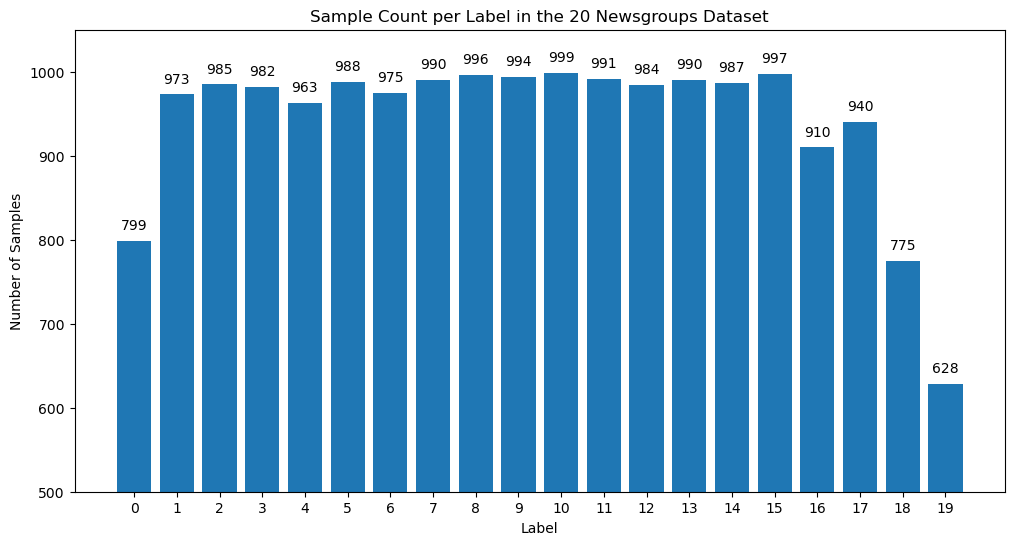

In [6]:
# Count the number of samples per label
unique, counts = np.unique(y, return_counts=True)

# Charting
plt.figure(figsize=(12, 6))
plt.bar(unique, counts, tick_label=unique)
plt.xlabel('Label')
plt.ylabel('Number of Samples')
plt.title('Sample Count per Label in the 20 Newsgroups Dataset')
plt.ylim(500, 1050)  # Set y-axis limits

# Add count labels on top of each bar for clarity
for i, count in zip(unique, counts):
    plt.text(i, count + 10, str(count), ha='center', va='bottom')

plt.show()

## Step 3: Train Classification Baseline Model
We use LinearSVC to establish a baseline model and evaluate its performance on the text dataset.

In [7]:
# Compute baseline accuracy using full-dimensional data with LinearSVC
baseline_model = LinearSVC(random_state=42, max_iter=1000, dual=True)
baseline_model.fit(X_train, y_train)  # Train model on full-dimensional data
baseline_pred = baseline_model.predict(X_test)  # Predict on test set
baseline_acc = accuracy_score(y_test, baseline_pred)  # Calculate accuracy
print(f"Baseline LinearSVC accuracy (full dimension): {baseline_acc:.4f}")

Baseline LinearSVC accuracy (full dimension): 0.8307


## Step 4: Train Classification Model with Random Projection
By applying Random Projection to the text dataset, we observe how the accuracy changes with varying dimensions and classify using Random Forest and SVC.

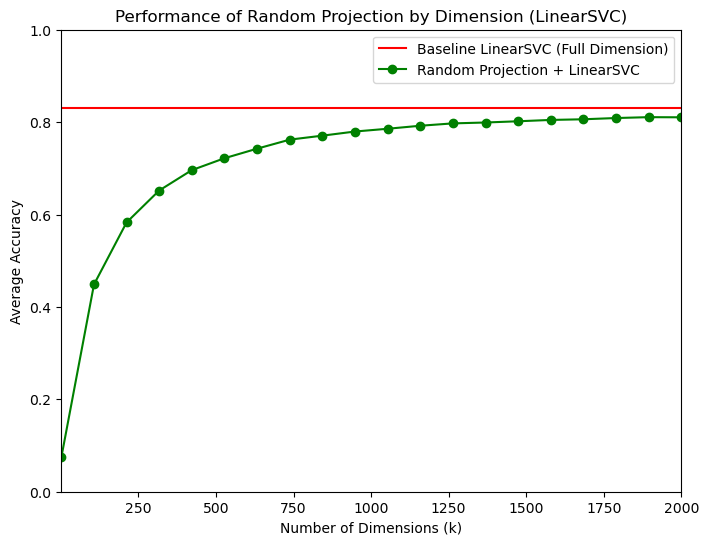

In [34]:
# Number of realizations for each projection dimension
realizations = 20

# Create an array of dimensions to test, from 2 to 2000 (full dimension), evenly spaced in 20 steps
dims = np.int32(np.linspace(2, 2000, 20))

# Initialize an array to store accuracies for each realization and dimension
accuracies = np.empty((realizations, len(dims)))

# Loop over the different projection dimensions (k)
for j, dim in enumerate(dims):
    for i in range(realizations):
        # Create a sparse random projection transformer with the current dimension 'dim'
        sp = SparseRandomProjection(n_components=dim, random_state=i)
        
        # Transform the training data using the random projection
        X_train_proj = sp.fit_transform(X_train)
        
        # Train a LinearSVC classifier on the projected training data
        model = LinearSVC(random_state=42, max_iter=5000, dual=True)
        model.fit(X_train_proj, y_train)
        
        # Project the test data using the same transformer
        X_test_proj = sp.transform(X_test)
        
        # Predict the labels on the projected test data
        y_pred = model.predict(X_test_proj)
        
        # Compute and store the accuracy for this realization and dimension
        accuracies[i, j] = accuracy_score(y_test, y_pred)

# Compute the average accuracy for each dimension value
average_acc = np.mean(accuracies, axis=0)

# Plot the baseline accuracy and the random projection accuracies
plt.figure(figsize=(8, 6))
plt.xlabel("Number of Dimensions (k)")
plt.ylabel("Average Accuracy")
plt.title("Performance of Random Projection by Dimension (LinearSVC)")
plt.xlim([dims[0], dims[-1]])
plt.ylim([0, 1])
plt.plot(dims, [baseline_acc] * len(average_acc), color="red", label="Baseline LinearSVC (Full Dimension)")
plt.plot(dims, average_acc, color="green", marker='o', label="Random Projection + LinearSVC")
plt.legend()
plt.show()

## Step 5: Get the JL Lemma Recommended Dimension
After analyzing the accuracy performance, we compare the results with the dimensions suggested by the JL Lemma to check for alignment.

In [8]:
from math import ceil, log

def jl_minimum_dimension(n, epsilon):
    """
    Compute the minimum dimension k suggested by the Johnson-Lindenstrauss lemma.
    
    Parameters:
        n (int): Number of points (e.g., number of training samples)
        epsilon (float): Distortion parameter (0 < epsilon < 1)
        
    Returns:
        int: The recommended minimum dimension k.
    """
    denominator = (epsilon**2) / 2 - (epsilon**3) / 3  # Formula as per JL lemma
    return ceil(4 * log(n) / denominator)

# Get the number of training samples from your dataset
n_train = X_train.shape[0]
epsilon = 0.3  # You can adjust this parameter as needed

# Calculate the recommended minimum dimension using JL lemma
recommended_k = jl_minimum_dimension(n_train, epsilon)
print(f"Recommended minimum dimension (k) according to JL lemma: {recommended_k}")

Recommended minimum dimension (k) according to JL lemma: 1055


## Step 6: Train the Same Dataset Using Random Forest with JL Lemma Dimensions
Using the dimension suggested by the JL Lemma, we apply Random Forest to the same dataset and evaluate whether accuracy is preserved.

In [9]:
# Set the target dimension to 1055 based on JL lemma
dim = 1055

# Create a SparseRandomProjection transformer with the fixed dimension
sp = SparseRandomProjection(n_components=dim, random_state=42)

# Transform the training and test data using the random projection
X_train_proj = sp.fit_transform(X_train)
X_test_proj = sp.transform(X_test)

# Train a Random Forest classifier on the projected training data
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_proj, y_train)

# Predict the labels on the projected test data
y_pred = model.predict(X_test_proj)

# Compute and print the accuracy for the fixed projection dimension
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with dimension {dim} using Random Forest: {accuracy:.4f}")

Accuracy with dimension 1055 using Random Forest: 0.6578


## Part 1 Key Takeaways:
**1. Classifier selection is important to assess whether Random Projection is effective in reducing dimensionality of datasets while still preserving its most significant features.** <br>
**1a. SVC performs better than Random Forest in this dataset:** Even with a significant reduction in dimensions (around 900 out of 2000), SVC maintained near-baseline accuracy, whereas Random Forest plateaued at ~300 dimensions and did not reach baseline performance. <br>

**1b. Model choice matters:** Linear models like SVC handle sparse, high-dimensional data better than Random Forest, which struggles with such data. SVC can achieve nearly baseline performance with reduced dimensions, making Random Projection a useful method for reducing computational cost.<br><br>

**2. There is a trade-off between Dimensionality and Accuracy.** As projection dimensions increase, accuracy improves and approaches the baseline, suggesting that dimensionality can be reduced from 2000 to around 1000 without significant performance loss. However, even with full dimensions, Random Projection doesn't exactly match the original feature space due to inherent randomness and averaging. <br><br>

**3. Although JL Lemma suggests a minimum number of dimensions, it does not guarantee that using this measure will yield to equal or higher accuracy results compared to the baseline.** JL Lemma suggests a minimum dimension of ~1055 to preserve pairwise distances, but accuracy does not always improve when following this. While LinearSVC performance improved near this dimension, Random Forest achieved only 66% accuracy in JL-projected space. While JL Lemma preserves distances, it doesn’t account for class separability or class labels, which are critical for effective classification.

# **Part 2: Image Dataset Modeling with SRP (Facial Emotion Detection)**
We apply the same SRP and classifier models to a facial emotion detection dataset. We aim to understand how the results differ when working with image data compared to text.

## Step 1: Fetch Data from Kaggle

In [10]:
# Disable file validation warning for debugger (set this before other imports)
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

# Download latest version from Kaggle
path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")
print("Downloaded files:", os.listdir(path))

csv_file = os.path.join(path, "data.csv")
image_root = os.path.join(path, "dataset")

def load_images_from_csv(df, image_root, size=(48, 48)):
    X = []
    y = []
    for i, row in df.iterrows():
        img_path = os.path.join(image_root, row['path'])  # Row includes both label and image path.
        try:
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize(size)  # Resize image to a fixed size (48x48)
            X.append(np.array(img).flatten())  # Flatten the image to a 1D array
            y.append(row['label'])
        except Exception as e:
            print(f"Extract data failing: {img_path}, Reason: {e}")
    return np.array(X), np.array(y)

# Specify cache directory and create it if it doesn't exist
cache_dir = "."
os.makedirs(cache_dir, exist_ok=True)

# Check if processed data is cached; if so, load the cache to accelerate startup.
cache_X = os.path.join(cache_dir, "X.npy")
cache_y = os.path.join(cache_dir, "y.npy")

if os.path.exists(cache_X) and os.path.exists(cache_y):
    print("Loading cached data...")
    X = np.load(cache_X)
    y = np.load(cache_y)
else:
    print("Reading images")
    df = pd.read_csv(csv_file)
    X, y = load_images_from_csv(df, image_root)
    np.save(cache_X, X)
    np.save(cache_y, y)

100%|█████████████████████████████████████████████████████████████████████████████| 1.98G/1.98G [12:09<00:00, 2.92MB/s]

Extracting files...


Downloaded files: ['data.csv', 'dataset']
Reading images


## Step 2: Confirm the Content of the Dataset

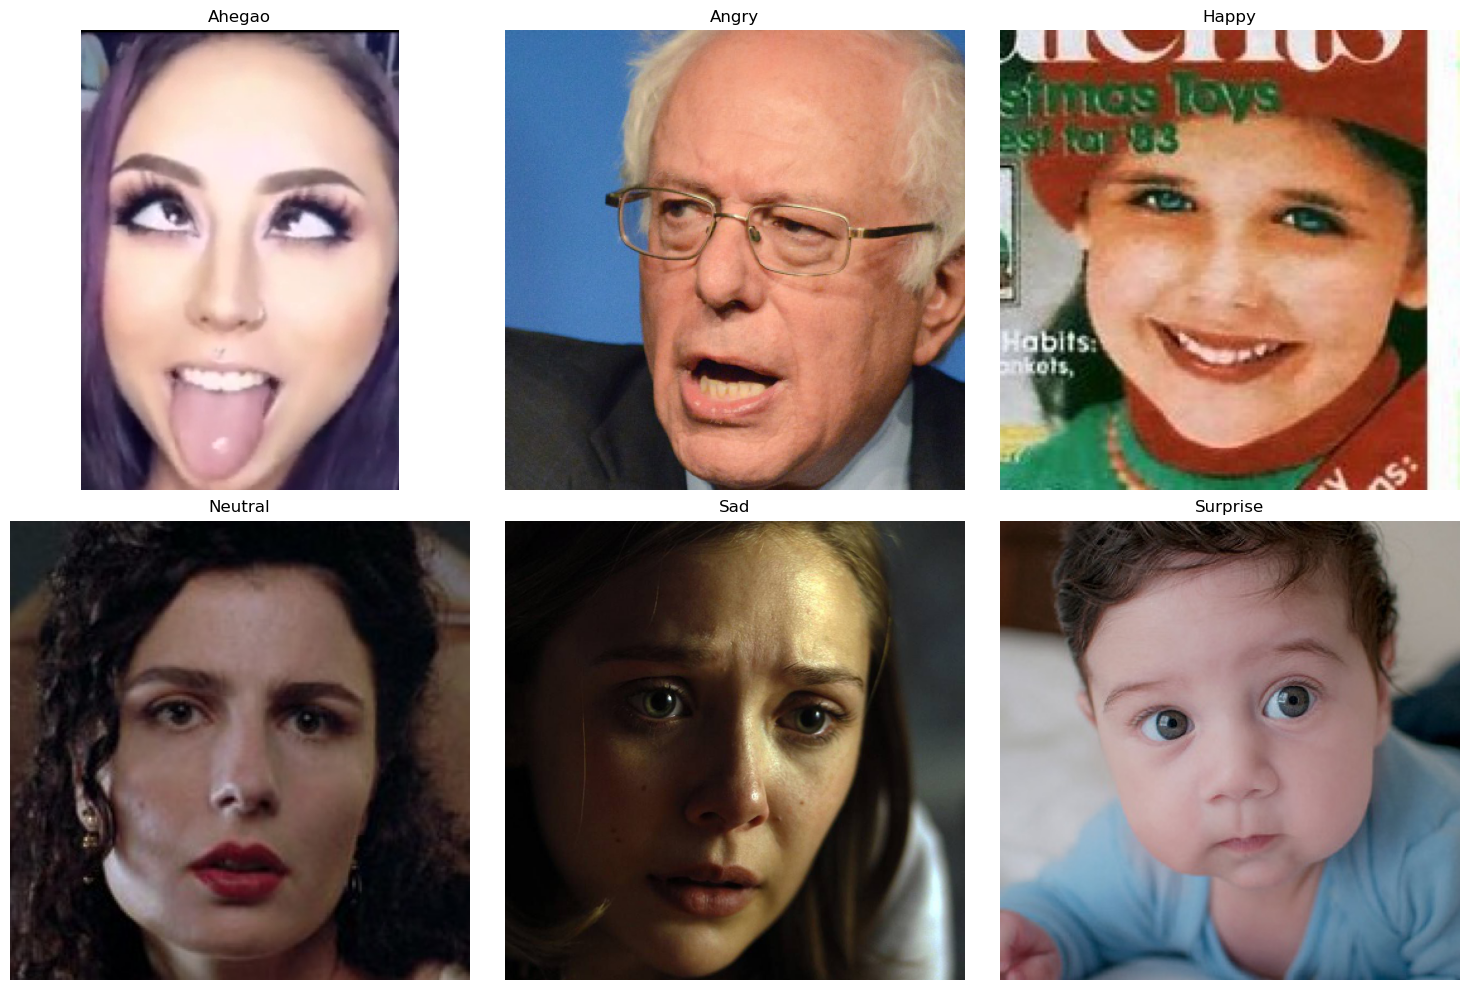

In [17]:
# First look at the pictures
emotions = ['Ahegao', 'Angry', 'Happy', 'Neutral', 'Sad', 'Surprise']

# Create subplot to display all 6 emotions
plt.figure(figsize=(15, 10))

for idx, emotion in enumerate(emotions, 1):
    emotion_path = os.path.join(image_root, emotion)  

    image_files = os.listdir(emotion_path)
    
    first_image = os.path.join(emotion_path, image_files[0])
    
    plt.subplot(2, 3, idx)
    img = Image.open(first_image)
    plt.imshow(img)
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))
unique, counts = np.unique(y, return_counts=True)
for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

X shape: (15453, 2304)
y shape: (15453,)
Unique labels: ['Ahegao' 'Angry' 'Happy' 'Neutral' 'Sad' 'Surprise']
Label Ahegao: 1205 samples
Label Angry: 1313 samples
Label Happy: 3740 samples
Label Neutral: 4027 samples
Label Sad: 3934 samples
Label Surprise: 1234 samples


## Step 3: Train Classification Model with Full Dataset (Baseline)
We train baseline models (Random Forest and SVC) on the raw image data to evaluate performance before applying SRP.

In [19]:
# Separate Training and Testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------Model building (including standardize)------------
# Use a single pipeline step to include standardization for both models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "SVC": SVC(kernel='rbf', gamma='scale')
}

# Create a standard scaler outside of the loop to apply it once
scaler = StandardScaler()

# ------------Training baseline model and get the accuracy------------
baseline_accuracies = {}
for name, model in models.items():
    # Apply standardization on both train and test data before fitting
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    start_time = time.time()
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    end_time = time.time()
    
    baseline_accuracies[name] = acc
    duration = end_time - start_time
    print(f"{name:<20}: baseline accuracy rate = {acc:.4f}| time used = {duration:.2f} sec")

Random Forest       : baseline accuracy rate = 0.4879| time used = 37.80 sec
SVC                 : baseline accuracy rate = 0.5349| time used = 368.88 sec


## Step 4: Train Classification Model with Random Projection
We apply Random Projection to the facial emotion dataset and evaluate the accuracy rate with different dimensions across models.

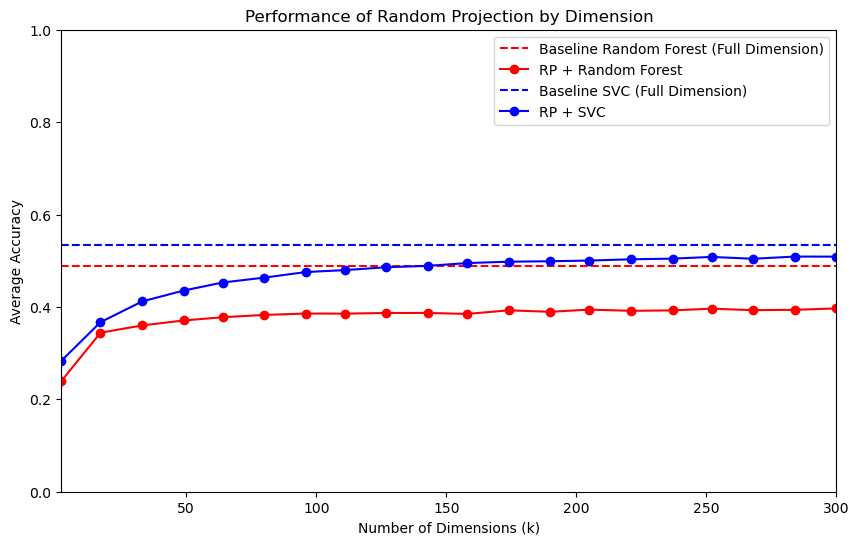

In [9]:
from joblib import Parallel, delayed # uses parallel processing to reduce runtime

# Define a range of projection dimensions to test and number of realizations
dims = np.int32(np.linspace(2, 300, 20))  # from 2 up to 300
realizations = 10  # number of random projection realizations per dimension

# Define the models we want to evaluate
model_names = ["Random Forest", "SVC"]

# Initialize a dictionary to store accuracies for each model (shape: [realizations, len(dims)])
results = {name: np.empty((realizations, len(dims))) for name in model_names}

def evaluate_model(dim, realization, model_name):
    # Create a sparse random projection transformer for current dimension 'dim'
    sp = SparseRandomProjection(n_components=dim, random_state=realization)
    # Project training and testing data
    X_train_proj = sp.fit_transform(X_train)
    X_test_proj  = sp.transform(X_test)
    # Create the classifier pipeline based on the model name
    if model_name == "Random Forest":
        clf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
    elif model_name == "SVC":
        clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', random_state=42))
    # Train and evaluate the model
    clf.fit(X_train_proj, y_train)
    y_pred = clf.predict(X_test_proj)
    return accuracy_score(y_test, y_pred)

# Loop over each projection dimension and each model, evaluating realizations in parallel
for j, dim in enumerate(dims):
    for model_name in model_names:
        accs = Parallel(n_jobs=-1)(
            delayed(evaluate_model)(dim, i, model_name) for i in range(realizations)
        )
        results[model_name][:, j] = accs

# Compute the average accuracy for each dimension (averaged over realizations)
average_acc = {name: np.mean(results[name], axis=0) for name in model_names}

# Plot the results
plt.figure(figsize=(10, 6))
plt.xlabel("Number of Dimensions (k)")
plt.ylabel("Average Accuracy")
plt.title("Performance of Random Projection by Dimension")

plt.plot(dims, [baseline_accuracies["Random Forest"]] * len(dims), color="red", linestyle="--",
         label="Baseline Random Forest")
plt.plot(dims, average_acc["Random Forest"], color="red", marker='o', label="RP + Random Forest")

plt.plot(dims, [baseline_accuracies["SVC"]] * len(dims), color="blue", linestyle="--",
         label="Baseline SVC")
plt.plot(dims, average_acc["SVC"], color="blue", marker='o', label="RP + SVC")

plt.xlim([dims[0], dims[-1]])
plt.ylim([0, 1])
plt.legend()
plt.show()

## Step 5: Get the JL Lemma Recommended Dimension
We compare the dimensions suggested by the JL Lemma to the empirical results for Random Projection.

In [20]:
# Get the number of training samples from your dataset
n_train = X.shape[0]
epsilon = 0.3  # You can adjust this parameter as needed

# Calculate the recommended minimum dimension using JL lemma
recommended_k = jl_minimum_dimension(n_train, epsilon)
print("Recommended minimum dimension (k) according to JL lemma:", recommended_k)

Recommended minimum dimension (k) according to JL lemma: 1072


## Part 2 Key Takeaways:
**1. There is a lower accuracy due to RP's limitations with complex non-linear images.** <br>
The lower accuracy when using Random Projection (RP) on facial emotion images stems from the complexity and nonlinearity of image data. For instance, when reducing dimensions to 200, the accuracy for SVC reached around 47% and for Random Forest, it plateaued at around 43%. The quick convergence observed in RP indicates that the model stabilizes at a low accuracy level without extracting the key features, demonstrating the inadequacy of RP for handling complex images. More advanced feature extraction methods that can better capture non-linear relationships are necessary for improving performance.

**2. SVC outperforms Random Forest in complex image datasets as well as texts.** <br>
Despite the challenges of using RP with raw image data, SVC consistently outperforms Random Forest. For both image and text datasets, SVC demonstrated better accuracy. With 200 dimensions, SVC achieved an accuracy of 47%, while Random Forest plateaued at 43%.

**3. Recommended minimum dimension (k) according to JL Lemma: 1072.** <br>
Although the JL Lemma suggests a minimum dimension of 1072 to preserve pairwise distances, our results show that even at this dimension, Random Projection did not reach baseline accuracy. SVC’s accuracy improved with higher dimensions but still did not match the baseline, highlighting that JL Lemma’s theoretical guidance on dimensionality doesn't always ensure optimal performance, especially with complex image data.

# **Part 3: Image Classification with advanced ML model**
Considering the result of part 2, we noticed the result didn't have good accuracy rate. Therefore, we try to fit the images data set with CNN model in order to enhance the accuracy rate. Also, through this project, we want to evalaute if the CNN model is more suitable for image classification.

Downloaded files: ['data.csv', 'dataset']


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 10s 1us/step
SVC Baseline Accuracy (Full Dimension): 0.6316


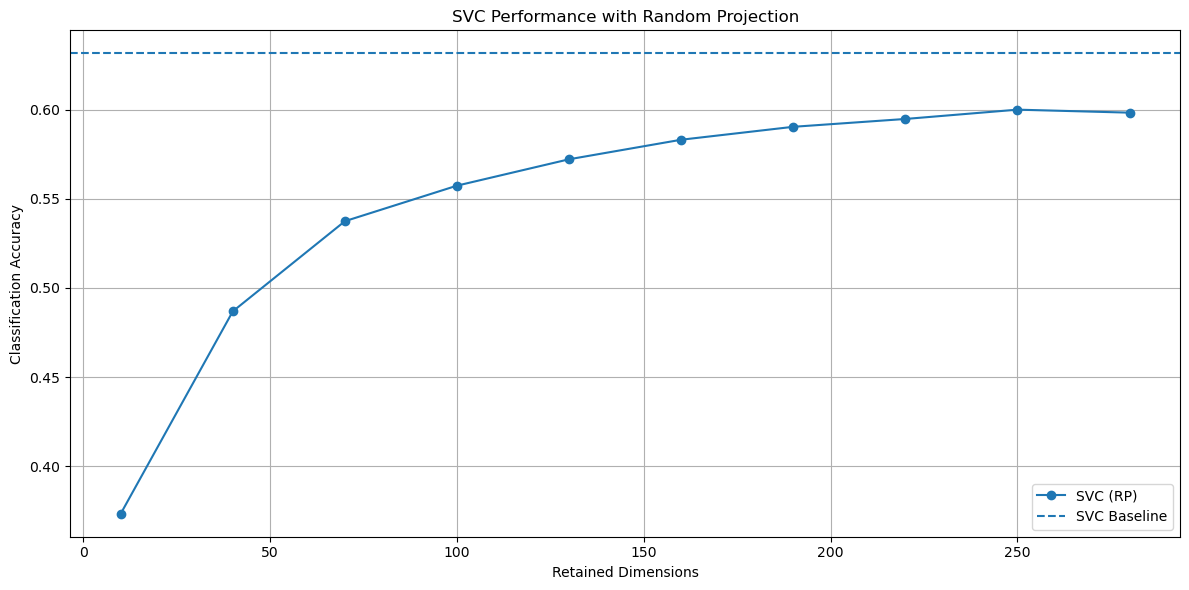

In [5]:
# Ensure path is defined properly
path = kagglehub.dataset_download("sujaykapadnis/emotion-recognition-dataset")
print("Downloaded files:", os.listdir(path))

csv_file = os.path.join(path, "data.csv")
root_path = os.path.join(path, "dataset")

# ---------------------------
# Data Loading & Preprocessing
# ---------------------------
# Read CSV and encode labels
df = pd.read_csv(csv_file)
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# Load and preprocess images for MobileNetV2 (expects 224x224 RGB images)
def load_and_extract_images(paths, size=(224, 224)):
    images = []
    for p in tqdm(paths, desc="Loading images", leave=False):
        full_path = os.path.join(root_path, p)
        try:
            img = load_img(full_path, target_size=size)
            img = img_to_array(img)
            img = preprocess_input(img)
            images.append(img)
        except Exception:
            continue
    return np.array(images)

X_images = load_and_extract_images(df['path'])
y = df['label_encoded'][:len(X_images)]

# Extract features using MobileNetV2 (without classifier head)
mobilenet = MobileNetV2(weights="imagenet", include_top=False, pooling="avg", input_shape=(224, 224, 3))
X_features = mobilenet.predict(X_images, batch_size=32, verbose=0)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=42)

# ---------------------------
# Baseline Model Training (SVC only)
# ---------------------------
base_model = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma='scale', random_state=42))
base_model.fit(X_train, y_train)
baseline_accuracy = base_model.score(X_test, y_test)
print(f"SVC Baseline Accuracy (Full Dimension): {baseline_accuracy:.4f}")

# ---------------------------
# Random Projection Experiments (SVC only)
# ---------------------------
# Define dimension range: from 10 up to min(feature_dim, 300) with step 30
max_dim = min(X_features.shape[1], 300)
dimensions = list(range(10, max_dim + 1, 30))
repeats = 5

# Create random projection function
def evaluate_model(base_model, dim, rep):
    rp = SparseRandomProjection(n_components=dim, random_state=rep)
    X_train_proj = rp.fit_transform(X_train)
    X_test_proj = rp.transform(X_test)
    
    model = clone(base_model)
    model.fit(X_train_proj, y_train)
    return model.score(X_test_proj, y_test)

# Evaluate SVC for each dimension (averaged over 'repeats' realizations)
results = []
for dim in dimensions:
    accs = Parallel(n_jobs=-1)(
        delayed(evaluate_model)(base_model, dim, rep) for rep in range(repeats)
    )
    results.append(np.mean(accs))

# ---------------------------
# Plotting Final Chart
# ---------------------------
plt.figure(figsize=(12, 6))
plt.plot(dimensions, results, marker='o', label="SVC (RP)")
plt.axhline(y=baseline_accuracy, linestyle='--', label="SVC Baseline")
plt.xlabel("Retained Dimensions")
plt.ylabel("Classification Accuracy")
plt.title("SVC Performance with Random Projection")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Part 3 Key Takeaway:**

**There is an improvement in accuracy in adding CNN to SRP for this dataset.** By incorporating MobileNetV2 (pre-trained CNN model) for feature extraction before classification, the accuracy of the SVC model increased from 53% (baseline) to 63%.

# **Conclusion**
Through our experiments across text and image datasets, we evaluated the impact of Sparse Random Projection (SRP) and various classifiers on classification performance, while comparing results with theoretical expectations from the Johnson-Lindenstrauss (JL) Lemma.


**1. How does the effectiveness of Sparse Random Projection (SRP) vary across different types of classifiers and different types of datasets?** <br>

**1a. Random Projection (RP) is effective for linear, high-dimensional data.** <br>
In the text dataset, SRP successfully reduced dimensions (from 2000 to ~1000) while preserving most classification performance—especially when combined with linear classifiers like SVC.

**1b. Classifier choice significantly impacts performance.** <br>
Across both datasets, SVC consistently outperformed Random Forest. Linear models (e.g., SVC) are more robust to RP’s transformations, especially in sparse or high-dimensional contexts, while Random Forest struggled with both text and image data post-RP.


**2. How does the dimensionality suggested by the JL Lemma correlate with classification accuracy?** <br>

**2a. JL Lemma provides a useful guidance for dimensions, but in practice, it has its limitations.** <br>
While JL Lemma provides a useful lower bound for dimensions (e.g., ~1055 for text, ~1072 for images), models trained at these dimensions did not always reach baseline accuracy. This is because JL Lemma only preserves pairwise distances—not class separability or task-specific features. Thus, there is a theoretical vs. empirical gap in using JL Lemma.

**2b. There are still model and data dependencies.** <br>
The effectiveness of JL Lemma’s suggested dimensionality depends on the nature of the dataset and the classifier used. It may align well with SVC on linear data, but offers less utility in complex, nonlinear domains.


**3. How does Random Projection affect the quality of feature representations in nonlinear datasets? Can combining Random Projection with deep learning techniques provide an efficient trade-off between dimensionality reduction and feature preservation?** <br>

**3a. Facial emotion images present nonlinear challenges.** <br>
In image datasets, RP struggled to preserve critical features, resulting in low accuracy (SVC ~47%, RF ~43% at 200 dimensions). The convergence of accuracy at low dimensions indicates RP flattens meaningful structures in the data.

**3b. Some datasets and models require the need for advanced feature extraction.** <br>
When MobileNetV2 (CNN) was introduced in Part 3, accuracy improved from 53% to 63%, showing that deep learning-based feature extraction is essential for nonlinear, visual data.

**In conclusion,** SRP is a lightweight and powerful tool for dimensionality reduction—especially for linear or sparse datasets—but its performance is tightly coupled with appropriate classifier selection. For nonlinear data such as images, SRP alone is insufficient, and more sophisticated models like CNNs are required to extract and preserve meaningful features for accurate classification.